In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('datasets/heart.csv')

#exploring datasets

In [3]:
df.shape

(303, 14)

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [5]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.tail()   

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [9]:
df.isnull().any()

age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [13]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

/tmp/ipykernel_71930/3550976346.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  g = df.hist(ax=ax)


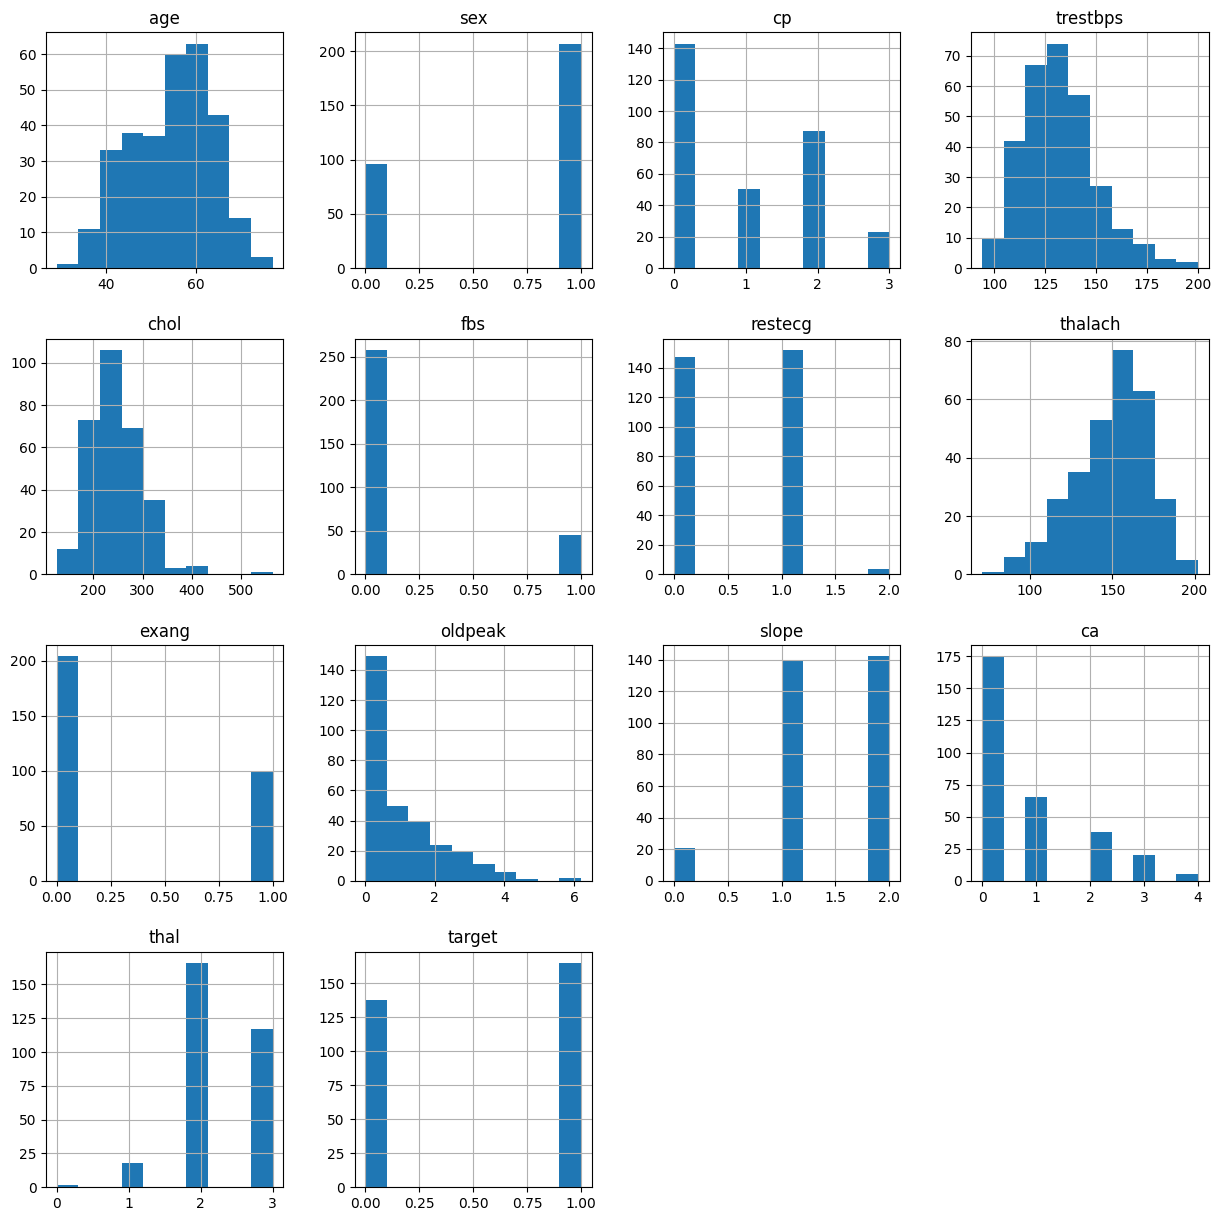

In [14]:
fig = plt.figure(figsize=(15, 15))
ax = fig.gca()
g = df.hist(ax=ax)

/tmp/ipykernel_71930/2816057645.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.countplot(x='target', data=df, palette='hls')


Text(0, 0.5, 'count')

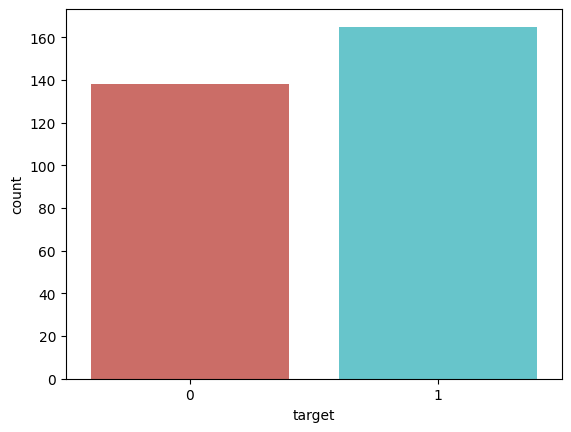

In [17]:
g = sns.countplot(x='target', data=df, palette='hls')
plt.xlabel('target')
plt.ylabel('count')

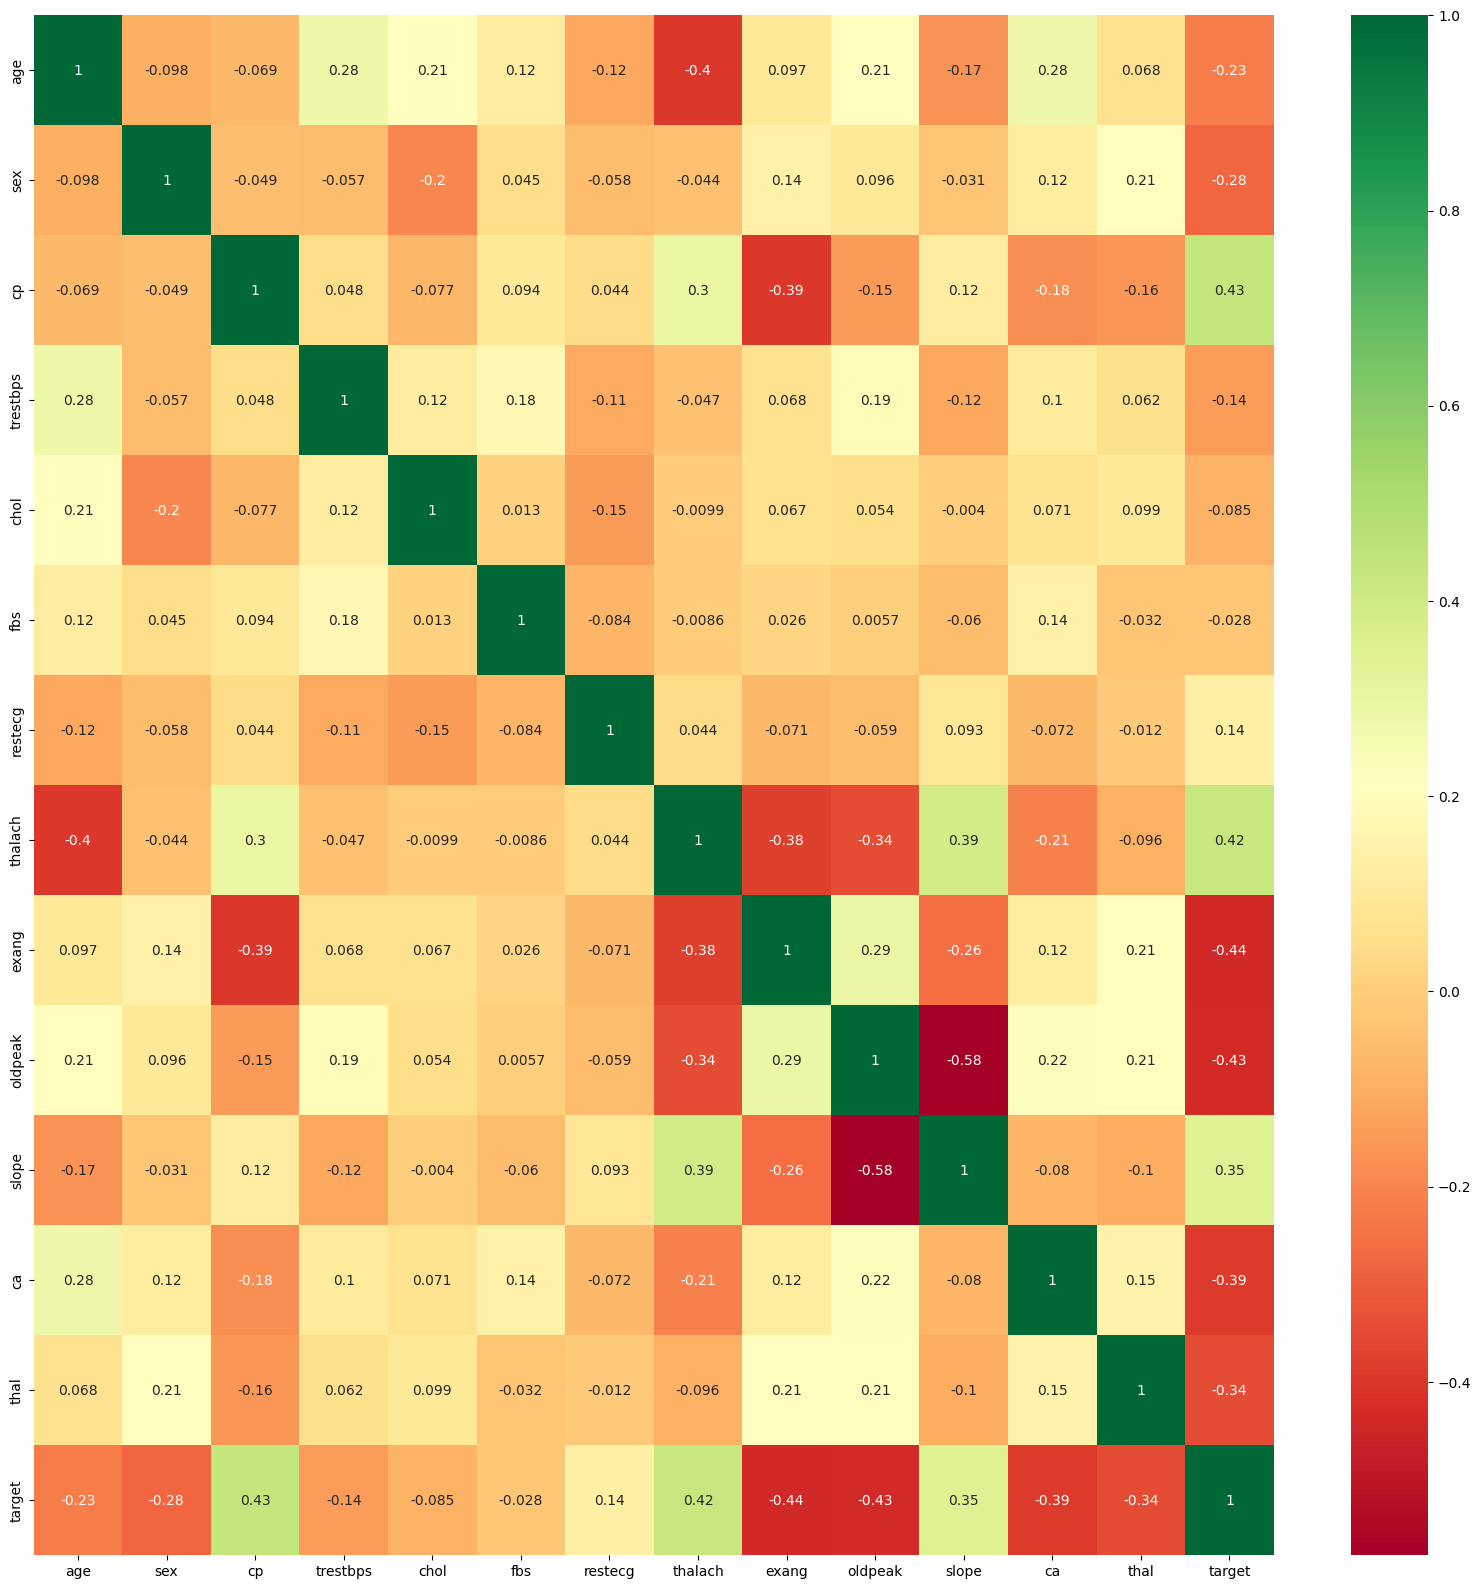

In [20]:
##feature engineering

#get correlation of all features in dataset
corr_matrix = df.corr()
top_corr_features = corr_matrix.index

#plotting the heatmap
plt.figure(figsize=(20,20))
#plot heat map
g = sns.heatmap(df[top_corr_features].corr(),annot=True,cmap="RdYlGn")  


In [21]:
#Data Preprocessing
dataset = pd.get_dummies(df, columns=['cp','sex','fbs','restecg','exang','slope','ca','thal'])

In [22]:
#Feature Scaling
dataset.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'cp_0',
       'cp_1', 'cp_2', 'cp_3', 'sex_0', 'sex_1', 'fbs_0', 'fbs_1', 'restecg_0',
       'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'slope_0', 'slope_1',
       'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'ca_4', 'thal_0', 'thal_1',
       'thal_2', 'thal_3'],
      dtype='object')

In [23]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
columns_to_scale = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
dataset[columns_to_scale] = standard_scaler.fit_transform(dataset[columns_to_scale])

In [24]:
dataset.head()

,age,trestbps,chol,thalach,oldpeak,target,cp_0,cp_1,cp_2,cp_3,...,slope_2,ca_0,ca_1,ca_2,ca_3,ca_4,thal_0,thal_1,thal_2,thal_3
0,0.952197,0.763956,-0.256334,0.015443,1.087338,1,False,False,False,True,...,False,True,False,False,False,False,False,True,False,False
1,-1.915313,-0.092738,0.072199,1.633471,2.122573,1,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
2,-1.474158,-0.092738,-0.816773,0.977514,0.310912,1,False,True,False,False,...,True,True,False,False,False,False,False,False,True,False
3,0.180175,-0.663867,-0.198357,1.239897,-0.206705,1,False,True,False,False,...,True,True,False,False,False,False,False,False,True,False
4,0.290464,-0.663867,2.082050,0.583939,-0.379244,1,True,False,False,False,...,True,True,False,False,False,False,False,False,True,False


In [25]:
#splitting the dataset into features and target variable
X = dataset.drop('target', axis=1)
y = dataset['target']

In [26]:
#building the model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier



In [27]:
knn_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10, scoring='accuracy')
    knn_scores.append(scores.mean())

Text(0, 0.5, 'Cross-Validated Accuracy')

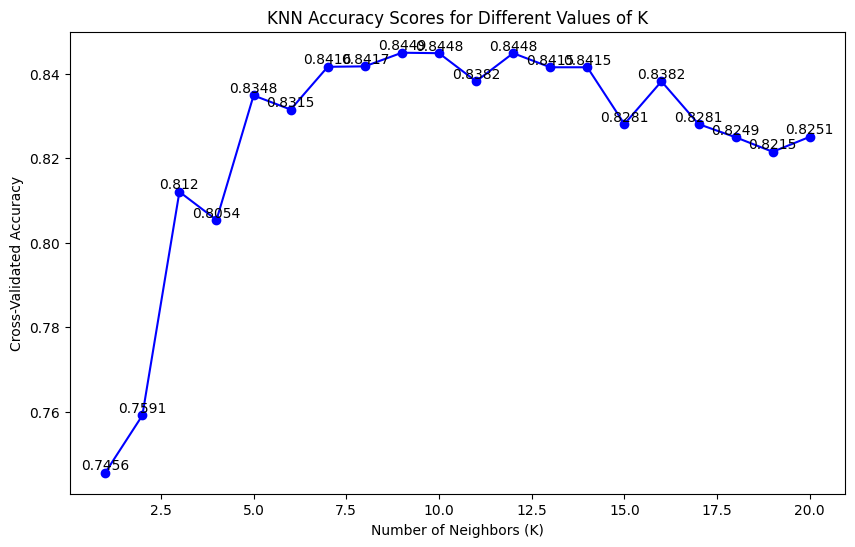

In [29]:
#plotting the accuracy scores for different values of k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), knn_scores, marker='o',color='blue')
for x in range(1, 21):
    plt.text(x, knn_scores[x-1], str(round(knn_scores[x-1], 4)), ha='center', va='bottom')  
plt.title('KNN Accuracy Scores for Different Values of K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validated Accuracy')  

In [31]:
knn_classifier = KNeighborsClassifier(n_neighbors=7)
cvs_scores = cross_val_score (knn_classifier, X, y, cv=10, scoring='accuracy')
print("Cross-validated accuracy score for KNN with k=7: {:.4f}".format(cvs_scores.mean()))

Cross-validated accuracy score for KNN with k=7: 0.8416


In [32]:
#decision tree classifier
from sklearn.tree import DecisionTreeClassifier 
decision_scores = []
for depth in range(1, 21):
    decision_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(decision_tree, X, y, cv=10, scoring='accuracy')
    decision_scores.append(scores.mean())

Text(0, 0.5, 'Cross-Validated Accuracy')

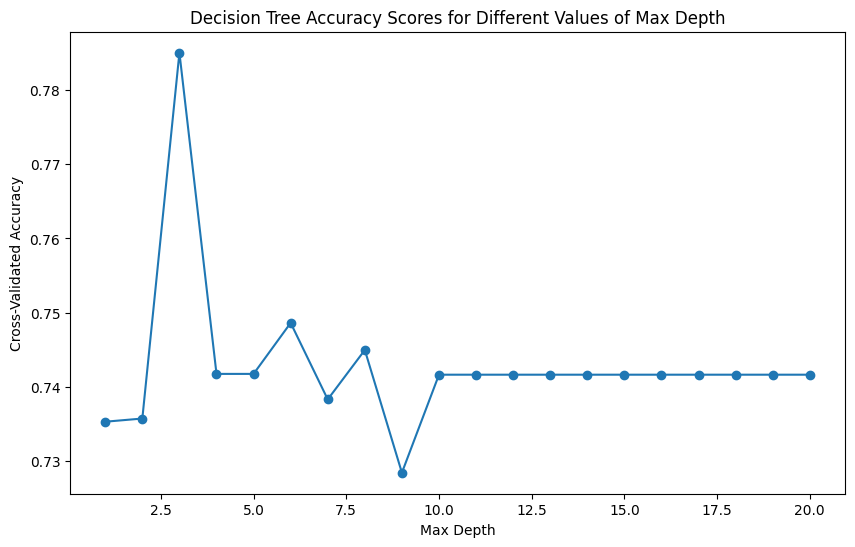

In [33]:
#plotting the accuracy scores for different values of k
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), decision_scores, marker='o')
plt.title('Decision Tree Accuracy Scores for Different Values of Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Cross-Validated Accuracy')     


In [34]:
decision_tree_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
cvs_scores = cross_val_score (decision_tree_classifier, X, y, cv=10, scoring='accuracy')
print("Cross-validated accuracy score for Decision Tree with max depth=5: {:.4f}".format(cvs_scores.mean()))

Cross-validated accuracy score for Decision Tree with max depth=5: 0.7417


In [35]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier 
forest_scores = []
for depth in range(10,101, 10):
    random_forest = RandomForestClassifier(n_estimators=depth)
    scores = cross_val_score(random_forest, X, y, cv=10, scoring='accuracy')
    forest_scores.append(scores.mean())

Text(0.5, 1.0, 'RandomForestClassifier score board')

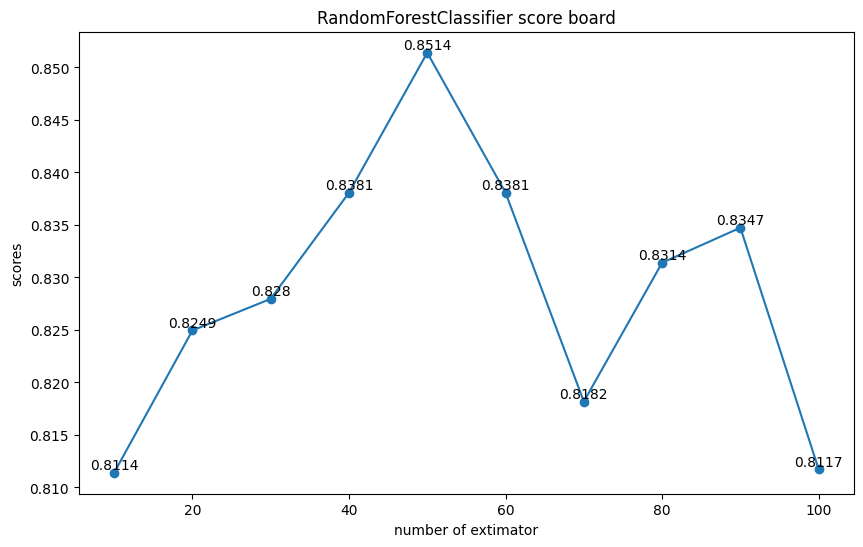

In [37]:
#plotting the accuracy scores for different values of n_estimators
plt.figure(figsize=(10, 6))
plt.plot(range(10,101, 10), forest_scores, marker='o')      
for x in range(10,101, 10):
    plt.text(x, forest_scores[(x//10)-1], str(round(forest_scores[(x//10)-1], 4)), ha='center', va='bottom')
plt.xlabel("number of extimator")
plt.ylabel('scores')
plt.title('RandomForestClassifier score board')

In [39]:
#training the random forest classifier with n value as 90
random_forest = RandomForestClassifier(n_estimators=90)
cvs_scores = cross_val_score(random_forest,X,y,cv=5)
print("RandomForestClassifier accuracy  ",cvs_scores.mean())

RandomForestClassifier accuracy   0.8283060109289618
